# Neural Network Architecture Comparison Study
## Applied AI I - Assignment 4

**Students:** Katrin Nguyen & Nico Loss  
**Dataset:** CIFAR-10  
**Framework:** PyTorch  
**Experiment Tracking:** Weights & Biases

---

## Research Question
"How do architectural choices (depth, width, regularization) affect neural network performance and training dynamics on image classification?"

## Objectives
- Compare MLP and CNN architectures systematically
- Analyze impact of depth and width on performance
- Study effects of regularization (dropout, batch normalization)
- Investigate learning rate influence on training dynamics
- Understand architectural trade-offs for image classification

## 1. Imports and Configuration

In [22]:
# ============================================
# Week 8: Neural Network Architecture Study
# Students: Katrin Nguyen & Nico Loss
# Dataset: CIFAR-10
# ============================================

# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import time
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Weights & Biases for experiment tracking
import wandb

# Styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

# Configuration
RANDOM_SEED = 42
BATCH_SIZE = 128
EPOCHS = 15
NUM_CLASSES = 10
IMG_SIZE = 32
IMG_CHANNELS = 3

# Reproducibility
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True

# Device configuration
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("✓ Using MPS (Metal Performance Shaders) on Mac")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("✓ Using CUDA")
else:
    device = torch.device("cpu")
    print("✓ Using CPU")

print(f"PyTorch Version: {torch.__version__}")
print(f"Device: {device}")
print(f"Random Seed: {RANDOM_SEED}")

✓ Using MPS (Metal Performance Shaders) on Mac
PyTorch Version: 2.9.1
Device: mps
Random Seed: 42


In [23]:
# Create figures directory for saving all visualizations
import os
os.makedirs('figures', exist_ok=True)
print("✓ Figures directory created/verified")

✓ Figures directory created/verified


## 2. Dataset Loading and Preprocessing

### CIFAR-10 Dataset
- **Image size:** 32×32 pixels (RGB)
- **Classes:** 10 (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck)
- **Training samples:** 50,000
- **Test samples:** 10,000
- **Preprocessing:** Normalization using CIFAR-10 statistics

In [24]:
# CIFAR-10 class names
CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
                   'dog', 'frog', 'horse', 'ship', 'truck']

# Data preprocessing and augmentation
# For training: normalize only (no augmentation for fair comparison)
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], 
                        std=[0.2470, 0.2435, 0.2616])
])

# For validation/test: same normalization
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], 
                        std=[0.2470, 0.2435, 0.2616])
])

# Load CIFAR-10 dataset
print("Loading CIFAR-10 dataset...")
train_dataset_full = datasets.CIFAR10(root='./data', train=True, 
                                      download=True, transform=train_transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, 
                                download=True, transform=test_transform)

# Create train/validation split (80/20)
train_size = int(0.8 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(
    train_dataset_full, [train_size, val_size],
    generator=torch.Generator().manual_seed(RANDOM_SEED)
)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, 
                         shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, 
                       shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, 
                        shuffle=False, num_workers=2, pin_memory=True)

print(f"\n✓ Dataset loaded successfully!")
print(f"  Training samples: {len(train_dataset):,}")
print(f"  Validation samples: {len(val_dataset):,}")
print(f"  Test samples: {len(test_dataset):,}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Number of batches - Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

Loading CIFAR-10 dataset...

✓ Dataset loaded successfully!
  Training samples: 40,000
  Validation samples: 10,000
  Test samples: 10,000
  Batch size: 128
  Number of batches - Train: 313, Val: 79, Test: 79


### 2.1 Dataset Visualization and Exploration

✓ Saved: figures/01_cifar10_sample_images.png


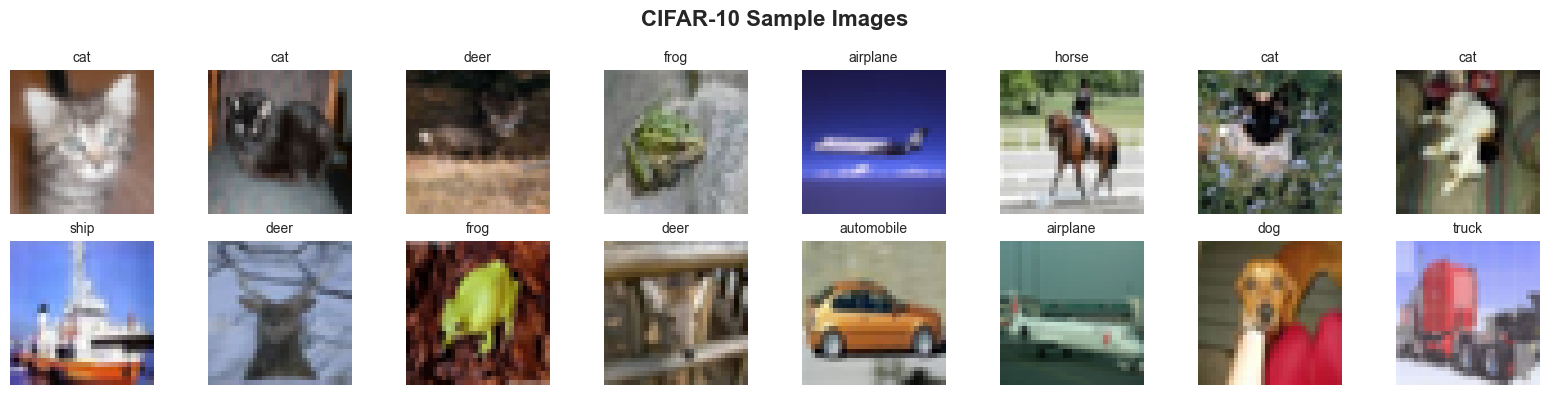

✓ Saved: figures/02_class_distribution.png


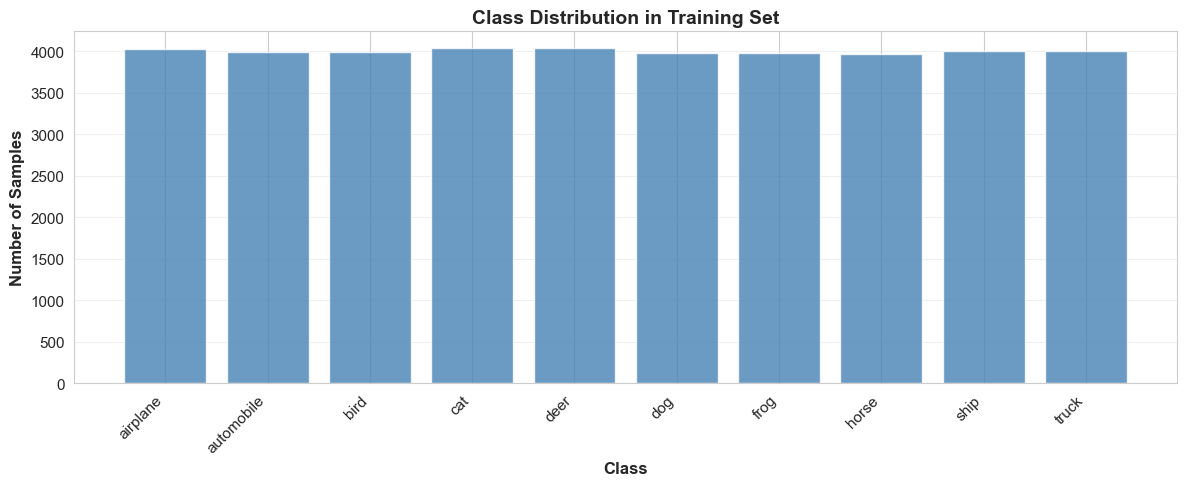


Class Distribution:
  airplane    : 4,027 samples (10.1%)
  automobile  : 3,990 samples (10.0%)
  bird        : 3,994 samples (10.0%)
  cat         : 4,033 samples (10.1%)
  deer        : 4,037 samples (10.1%)
  dog         : 3,976 samples (9.9%)
  frog        : 3,975 samples (9.9%)
  horse       : 3,965 samples (9.9%)
  ship        : 4,002 samples (10.0%)
  truck       : 4,001 samples (10.0%)


In [25]:
# Helper function to denormalize images for visualization
def denormalize(img):
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
    return img * std + mean

# Visualize sample images
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle('CIFAR-10 Sample Images', fontsize=16, fontweight='bold')

# Get a batch from the training loader
dataiter = iter(train_loader)
images, labels = next(dataiter)

for idx, ax in enumerate(axes.flat):
    if idx < 16:
        img = denormalize(images[idx].cpu())
        img = img.permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        
        ax.imshow(img)
        ax.set_title(f'{CIFAR10_CLASSES[labels[idx].item()]}', fontsize=10)
        ax.axis('off')

plt.tight_layout()
plt.savefig('figures/01_cifar10_sample_images.png', dpi=300, bbox_inches='tight')
print("✓ Saved: figures/01_cifar10_sample_images.png")
plt.show()

# Check class distribution
train_labels = [train_dataset_full.targets[i] for i in train_dataset.indices]
class_counts = pd.Series(train_labels).value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.bar(range(10), class_counts.values, color='steelblue', alpha=0.8)
plt.xlabel('Class', fontsize=12, fontweight='bold')
plt.ylabel('Number of Samples', fontsize=12, fontweight='bold')
plt.title('Class Distribution in Training Set', fontsize=14, fontweight='bold')
plt.xticks(range(10), CIFAR10_CLASSES, rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figures/02_class_distribution.png', dpi=300, bbox_inches='tight')
print("✓ Saved: figures/02_class_distribution.png")
plt.show()

print("\nClass Distribution:")
for idx, count in enumerate(class_counts.values):
    print(f"  {CIFAR10_CLASSES[idx]:12s}: {count:,} samples ({count/len(train_labels)*100:.1f}%)")

## 3. Model Architectures

We implement four architectures as specified in the assignment:

### Architecture A: Simple MLP
- Input (3072) → Dense(128) → ReLU → Dense(10) → Softmax
- Shallow network with single hidden layer
- Flattens spatial structure

### Architecture B: Deep MLP  
- Input (3072) → Dense(256) → ReLU → Dense(128) → ReLU → Dense(64) → ReLU → Dense(10)
- Multiple hidden layers with decreasing width
- More capacity but still ignores spatial structure

### Architecture C: Simple CNN
- Input → Conv(32, 3×3) → ReLU → MaxPool(2×2) → Flatten → Dense(128) → Dense(10)
- Single convolutional layer
- Preserves spatial information

### Architecture D: Deeper CNN
- Input → Conv(32) → BN → ReLU → MaxPool → Conv(64) → BN → ReLU → MaxPool → Flatten → Dense(256) → Dense(10)
- Multiple conv layers with batch normalization
- Hierarchical feature learning

In [26]:
# Architecture A: Simple MLP
class SimpleMLP(nn.Module):
    """
    Simple MLP with one hidden layer.
    Architecture: Input (3072) → Dense(128) → ReLU → Dense(10)
    """
    def __init__(self, input_size=3072, hidden_size=128, num_classes=10, dropout_rate=0.0):
        super(SimpleMLP, self).__init__()
        self.flatten = nn.Flatten()
        
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout_rate) if dropout_rate > 0 else nn.Identity(),
            nn.Linear(hidden_size, num_classes)
        )
    
    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)


# Architecture B: Deep MLP
class DeepMLP(nn.Module):
    """
    Deep MLP with multiple hidden layers.
    Architecture: Input → Dense(256) → ReLU → Dense(128) → ReLU → Dense(64) → ReLU → Dense(10)
    """
    def __init__(self, input_size=3072, num_classes=10, dropout_rate=0.0):
        super(DeepMLP, self).__init__()
        self.flatten = nn.Flatten()
        
        layers = []
        layers.append(nn.Linear(input_size, 256))
        layers.append(nn.ReLU())
        if dropout_rate > 0:
            layers.append(nn.Dropout(dropout_rate))
        
        layers.append(nn.Linear(256, 128))
        layers.append(nn.ReLU())
        if dropout_rate > 0:
            layers.append(nn.Dropout(dropout_rate))
        
        layers.append(nn.Linear(128, 64))
        layers.append(nn.ReLU())
        if dropout_rate > 0:
            layers.append(nn.Dropout(dropout_rate))
        
        layers.append(nn.Linear(64, num_classes))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        x = self.flatten(x)
        return self.network(x)


# Architecture C: Simple CNN
class SimpleCNN(nn.Module):
    """
    Simple CNN with one conv layer.
    Architecture: Input → Conv(32, 3×3) → ReLU → MaxPool(2×2) → Flatten → Dense(128) → Dense(10)
    """
    def __init__(self, num_classes=10, dropout_rate=0.0):
        super(SimpleCNN, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)  # 32×32 → 16×16
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 16 * 16, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate) if dropout_rate > 0 else nn.Identity(),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Architecture D: Deeper CNN
class DeeperCNN(nn.Module):
    """
    Deeper CNN with batch normalization.
    Architecture: Input → Conv(32) → BN → ReLU → MaxPool → 
                  Conv(64) → BN → ReLU → MaxPool → Flatten → Dense(256) → Dense(10)
    """
    def __init__(self, num_classes=10, dropout_rate=0.0, use_bn=True):
        super(DeeperCNN, self).__init__()
        
        # First conv block
        layers1 = [nn.Conv2d(3, 32, kernel_size=3, padding=1)]
        if use_bn:
            layers1.append(nn.BatchNorm2d(32))
        layers1.append(nn.ReLU())
        layers1.append(nn.MaxPool2d(kernel_size=2, stride=2))  # 32×32 → 16×16
        
        # Second conv block
        layers2 = [nn.Conv2d(32, 64, kernel_size=3, padding=1)]
        if use_bn:
            layers2.append(nn.BatchNorm2d(64))
        layers2.append(nn.ReLU())
        layers2.append(nn.MaxPool2d(kernel_size=2, stride=2))  # 16×16 → 8×8
        
        self.features = nn.Sequential(*(layers1 + layers2))
        
        # Classifier
        classifier_layers = [nn.Flatten(), nn.Linear(64 * 8 * 8, 256), nn.ReLU()]
        if dropout_rate > 0:
            classifier_layers.append(nn.Dropout(dropout_rate))
        classifier_layers.append(nn.Linear(256, num_classes))
        
        self.classifier = nn.Sequential(*classifier_layers)
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Utility function to count parameters
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Test all architectures
print("="*70)
print("MODEL ARCHITECTURES SUMMARY")
print("="*70)

models_test = [
    ("Architecture A: Simple MLP", SimpleMLP()),
    ("Architecture B: Deep MLP", DeepMLP()),
    ("Architecture C: Simple CNN", SimpleCNN()),
    ("Architecture D: Deeper CNN", DeeperCNN())
]

for name, model in models_test:
    model = model.to(device)
    params = count_parameters(model)
    print(f"\n{name}")
    print(f"  Parameters: {params:,}")
    
    # Test with dummy input
    dummy_input = torch.randn(1, 3, 32, 32).to(device)
    output = model(dummy_input)
    print(f"  Output shape: {output.shape}")
    print(f"  ✓ Architecture validated")

print("\n" + "="*70)

MODEL ARCHITECTURES SUMMARY

Architecture A: Simple MLP
  Parameters: 394,634
  Output shape: torch.Size([1, 10])
  ✓ Architecture validated

Architecture B: Deep MLP
  Parameters: 828,490
  Output shape: torch.Size([1, 10])
  ✓ Architecture validated

Architecture C: Simple CNN
  Parameters: 1,050,890
  Output shape: torch.Size([1, 10])
  ✓ Architecture validated

Architecture D: Deeper CNN
  Parameters: 1,070,986
  Output shape: torch.Size([1, 10])
  ✓ Architecture validated



## 4. Training and Evaluation Functions

Generic training and evaluation functions with Weights & Biases integration.

In [27]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """
    Train the model for one epoch.
    
    Returns:
        avg_loss: Average loss over all batches
        accuracy: Training accuracy
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(dataloader, desc='Training', leave=False)
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = running_loss / len(dataloader)
    accuracy = 100 * correct / total
    
    return avg_loss, accuracy


def evaluate(model, dataloader, criterion, device):
    """
    Evaluate the model on the given dataset.
    
    Returns:
        avg_loss: Average loss
        accuracy: Accuracy
        precision: Precision (macro-averaged)
        recall: Recall (macro-averaged)
        f1: F1-Score (macro-averaged)
        all_preds: All predictions
        all_labels: All true labels
    """
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    avg_loss = running_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds) * 100
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0) * 100
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0) * 100
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0) * 100
    
    return avg_loss, accuracy, precision, recall, f1, all_preds, all_labels


def train_model(model, train_loader, val_loader, criterion, optimizer, 
                num_epochs, device, model_name="Model", use_wandb=False, patience=3, use_scheduler=False):
    """
    Complete training process with history tracking and optional wandb logging.
    
    Returns:
        history: Dictionary with training history
    """
    # Scheduler initialisieren
    scheduler = None
    if use_scheduler:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=1)

    # Variablen für Early Stopping
    best_val_loss = float('inf')
    patience_counter = 0

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'val_precision': [], 'val_recall': [], 'val_f1': []
    }
    
    best_val_acc = 0.0
    best_epoch = 0
    
    print(f"\n{'='*70}")
    print(f"Training: {model_name}")
    print(f"{'='*70}\n")
    
    for epoch in range(num_epochs):
        start_time = time.time()
        
        # Training
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Validation
        val_loss, val_acc, val_prec, val_rec, val_f1, _, _ = evaluate(
            model, val_loader, criterion, device
        )
        
        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_precision'].append(val_prec)
        history['val_recall'].append(val_rec)
        history['val_f1'].append(val_f1)

        # Track best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1

        # Early Stopping basierend auf Validation Loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            print(f"→ New best validation loss: {val_loss:.4f}")
        else:
            patience_counter += 1
            print(f"→ No improvement for {patience_counter}/{patience} epochs")
            if patience_counter >= patience:
                print(f"\n{'='*70}")
                print(f"Early Stopping triggered after {epoch + 1} epochs!")
                print(f"No improvement in validation loss for {patience} consecutive epochs.")
                print(f"{'='*70}\n")
                break

        # Learning Rate Scheduler
        if use_scheduler and scheduler is not None:
            scheduler.step(val_loss)
        
        epoch_time = time.time() - start_time
        
        # Log to wandb
        if use_wandb:
            wandb.log({
                'epoch': epoch + 1,
                'train_loss': train_loss,
                'train_acc': train_acc,
                'val_loss': val_loss,
                'val_acc': val_acc,
                'val_precision': val_prec,
                'val_recall': val_rec,
                'val_f1': val_f1,
                'epoch_time': epoch_time
            })
        
        # Print progress
        print(f"Epoch [{epoch+1:2d}/{num_epochs}] | "
              f"Time: {epoch_time:.2f}s | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    
    print(f"\n{'='*70}")
    print(f"Training completed!")
    print(f"Best Validation Accuracy: {best_val_acc:.2f}% (Epoch {best_epoch})")
    print(f"Best Validation Loss: {best_val_loss:.4f}")
    print(f"{'='*70}\n")
    
    return history


print("✓ Training and evaluation functions defined")

✓ Training and evaluation functions defined


## 5. Experiment 1: MLP Depth and Width Study

### Research Questions:
- Does deeper always mean better?
- What is the effect of width?
- How many parameters does each variant have?
- Which shows overfitting?

### Experiments:
1. Simple MLP (Architecture A) with different widths: 64, 128, 256, 512
2. Deep MLP (Architecture B)
3. Compare depth vs. width trade-offs

In [28]:
# Initialize wandb for Experiment 1
# Note: You need to login to wandb first: wandb login
# wandb.login()  # Uncomment and run once to login

# Dictionary to store all results
exp1_results = {}

# Test different widths for Simple MLP
widths = [64, 128, 256, 512]
learning_rate = 0.001

print("\n" + "="*70)
print("EXPERIMENT 1: MLP DEPTH AND WIDTH STUDY")
print("="*70)

for width in widths:
    experiment_name = f"SimpleMLP_Width{width}"
    print(f"\n{'='*70}")
    print(f"Training: {experiment_name}")
    print(f"{'='*70}")
    
    # Initialize wandb run
    run = wandb.init(
        project="neural-network-architecture-study",
        name=experiment_name,
        config={
            "architecture": "Simple MLP",
            "width": width,
            "learning_rate": learning_rate,
            "epochs": EPOCHS,
            "batch_size": BATCH_SIZE,
            "dataset": "CIFAR-10"
        },
        reinit=True
    )
    
    # Create model
    model = SimpleMLP(input_size=3072, hidden_size=width, num_classes=10).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Log model info
    wandb.config.update({"parameters": count_parameters(model)})
    
    # Train
    history = train_model(
        model, train_loader, val_loader, criterion, optimizer,
        EPOCHS, device, experiment_name, use_wandb=True, patience=3, use_scheduler=True
    )
    
    # Test evaluation
    test_loss, test_acc, test_prec, test_rec, test_f1, test_preds, test_labels = evaluate(
        model, test_loader, criterion, device
    )
    
    # Log test results
    wandb.log({
        'test_loss': test_loss,
        'test_acc': test_acc,
        'test_precision': test_prec,
        'test_recall': test_rec,
        'test_f1': test_f1
    })
    
    # Store results
    exp1_results[experiment_name] = {
        'model': 'Simple MLP',
        'width': width,
        'parameters': count_parameters(model),
        'history': history,
        'test_acc': test_acc,
        'test_loss': test_loss,
        'best_val_acc': max(history['val_acc'])
    }
    
    wandb.finish()

# Now train Deep MLP (Architecture B)
experiment_name = "DeepMLP"
print(f"\n{'='*70}")
print(f"Training: {experiment_name}")
print(f"{'='*70}")

run = wandb.init(
    project="neural-network-architecture-study",
    name=experiment_name,
    config={
        "architecture": "Deep MLP",
        "layers": "256-128-64",
        "learning_rate": learning_rate,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "dataset": "CIFAR-10"
    },
    reinit=True
)

model = DeepMLP(input_size=3072, num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

wandb.config.update({"parameters": count_parameters(model)})

history = train_model(
    model, train_loader, val_loader, criterion, optimizer,
    EPOCHS, device, experiment_name, use_wandb=True, patience=3, use_scheduler=True
)

test_loss, test_acc, test_prec, test_rec, test_f1, test_preds, test_labels = evaluate(
    model, test_loader, criterion, device
)

wandb.log({
    'test_loss': test_loss,
    'test_acc': test_acc,
    'test_precision': test_prec,
    'test_recall': test_rec,
    'test_f1': test_f1
})

exp1_results[experiment_name] = {
    'model': 'Deep MLP',
    'width': '256-128-64',
    'parameters': count_parameters(model),
    'history': history,
    'test_acc': test_acc,
    'test_loss': test_loss,
    'best_val_acc': max(history['val_acc'])
}

wandb.finish()

print("\n✓ Experiment 1 completed!")


EXPERIMENT 1: MLP DEPTH AND WIDTH STUDY

Training: SimpleMLP_Width64



Training: SimpleMLP_Width64



→ New best validation loss: 1.6206
Epoch [ 1/15] | Time: 28.10s | Train Loss: 1.7266 | Train Acc: 39.51% | Val Loss: 1.6206 | Val Acc: 44.13%


→ New best validation loss: 1.5441
Epoch [ 2/15] | Time: 27.93s | Train Loss: 1.5226 | Train Acc: 46.81% | Val Loss: 1.5441 | Val Acc: 46.58%


→ New best validation loss: 1.5161
Epoch [ 3/15] | Time: 27.94s | Train Loss: 1.4400 | Train Acc: 49.66% | Val Loss: 1.5161 | Val Acc: 47.25%


...

→ No improvement for 1/3 epochs
Epoch [ 8/15] | Time: 27.84s | Train Loss: 0.8692 | Train Acc: 69.59% | Val Loss: 1.3364 | Val Acc: 55.33%


→ No improvement for 2/3 epochs
Epoch [ 9/15] | Time: 27.84s | Train Loss: 0.8384 | Train Acc: 70.75% | Val Loss: 1.3497 | Val Acc: 55.58%


→ No improvement for 3/3 epochs

Early Stopping triggered after 10 epochs!
No improvement in validation loss for 3 consecutive epochs.


Training completed!
Best Validation Accuracy: 55.82% (Epoch 10)
Best Validation Loss: 1.3312



epoch,▁▂▃▄▅▅▆▇█
epoch_time,█▄▄▅▆▃▁▁▁
test_acc,▁
test_f1,▁
test_loss,▁
test_precision,▁
test_recall,▁
train_acc,▁▃▄▄▅▆▇██
train_loss,█▆▅▅▄▃▂▁▁
val_acc,▁▃▅▆▅▆███
+4,...



✓ Experiment 1 completed!


### Experiment 1: Analysis and Visualization


EXPERIMENT 1 RESULTS: MLP DEPTH AND WIDTH COMPARISON
             Model Width/Layers Parameters Best Val Acc Test Acc Test Loss
 SimpleMLP_Width64           64    197,322       51.85%   51.36%    1.4154
SimpleMLP_Width128          128    394,634       54.03%   52.81%    1.3638
SimpleMLP_Width256          256    789,258       55.22%   54.01%    1.3895
SimpleMLP_Width512          512  1,578,506       55.08%   54.01%    1.3198
           DeepMLP   256-128-64    828,490       55.82%   54.65%    1.3541

✓ Saved: figures/03_experiment1_mlp_depth_width.png


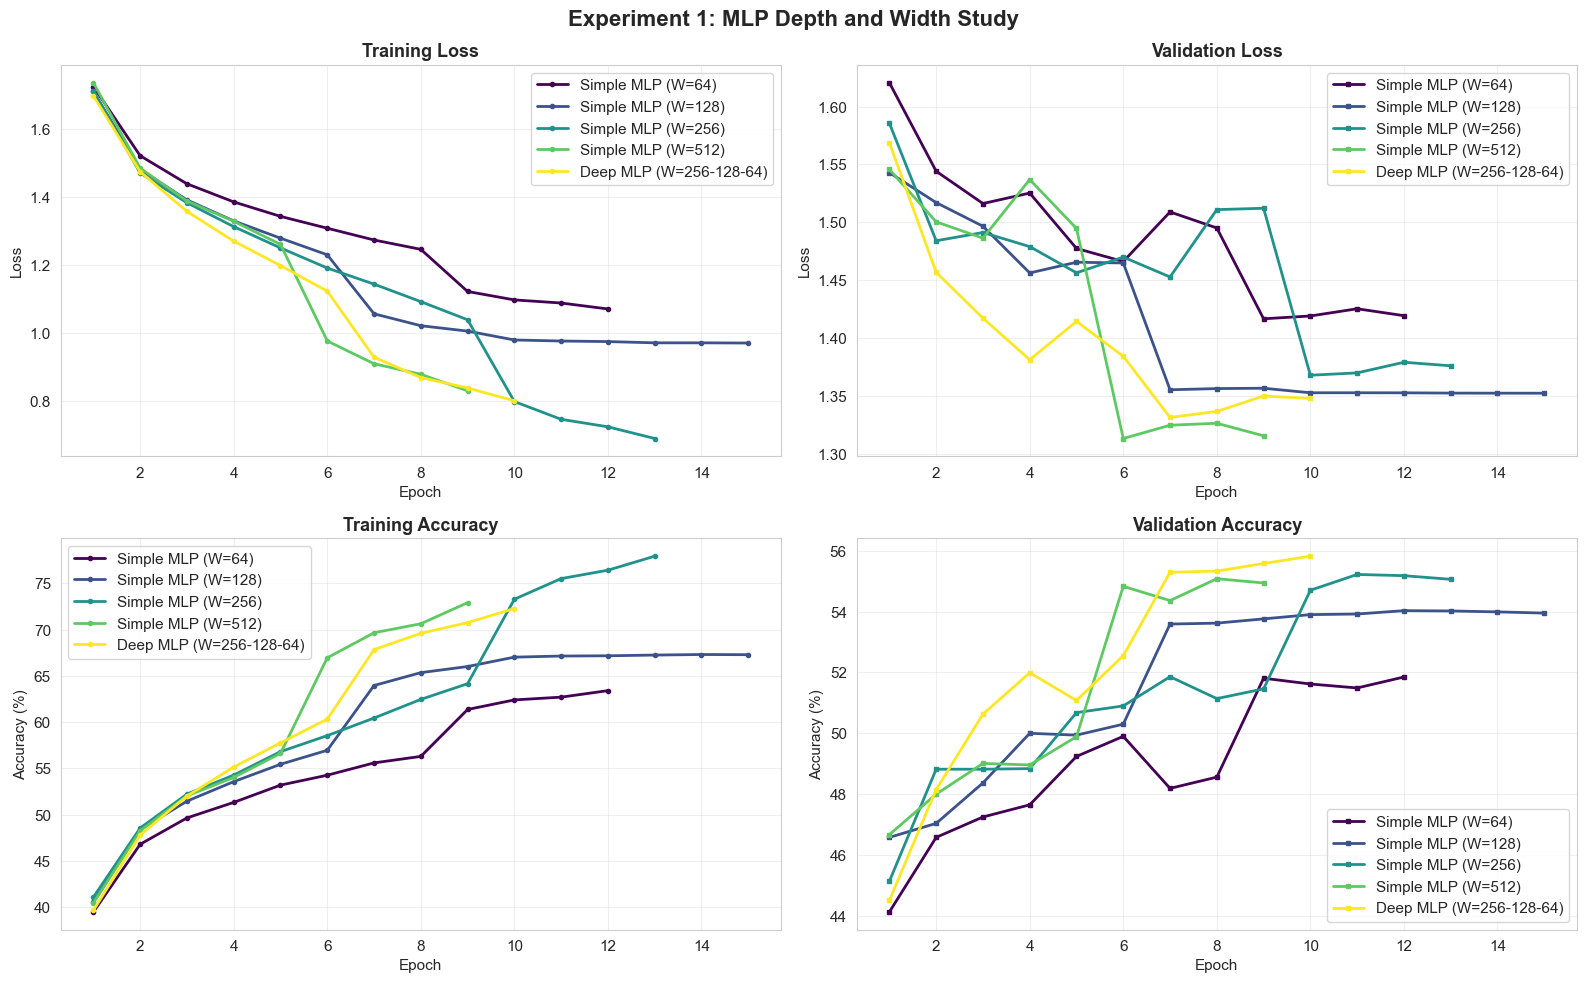


Overfitting Analysis (Train-Val Accuracy Gap at final epoch):
  SimpleMLP_Width64        :  11.55% gap
  SimpleMLP_Width128       :  13.34% gap
  SimpleMLP_Width256       :  22.86% gap
  SimpleMLP_Width512       :  17.96% gap
  DeepMLP                  :  16.45% gap


In [54]:
# Create comparison table
exp1_df = pd.DataFrame([
    {
        'Model': name,
        'Width/Layers': results['width'],
        'Parameters': f"{results['parameters']:,}",
        'Best Val Acc': f"{results['best_val_acc']:.2f}%",
        'Test Acc': f"{results['test_acc']:.2f}%",
        'Test Loss': f"{results['test_loss']:.4f}"
    }
    for name, results in exp1_results.items()
])

print("\n" + "="*90)
print("EXPERIMENT 1 RESULTS: MLP DEPTH AND WIDTH COMPARISON")
print("="*90)
print(exp1_df.to_string(index=False))
print("="*90 + "\n")

# Visualize learning curves
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Experiment 1: MLP Depth and Width Study', fontsize=16, fontweight='bold')

colors = plt.cm.viridis(np.linspace(0, 1, len(exp1_results)))

for idx, (name, results) in enumerate(exp1_results.items()):
    history = results['history']
    label = f"{results['model']} (W={results['width']})"

    # FIX: Define x-axis based on the actual length of this model's history
    epochs = range(1, len(history['train_loss']) + 1)

    # Training Loss
    axes[0, 0].plot(epochs, history['train_loss'], label=label,
                   color=colors[idx], linewidth=2, marker='o', markersize=3)

    # Validation Loss
    axes[0, 1].plot(epochs, history['val_loss'], label=label,
                   color=colors[idx], linewidth=2, marker='s', markersize=3)

    # Training Accuracy
    axes[1, 0].plot(epochs, history['train_acc'], label=label,
                   color=colors[idx], linewidth=2, marker='o', markersize=3)

    # Validation Accuracy
    axes[1, 1].plot(epochs, history['val_acc'], label=label,
                   color=colors[idx], linewidth=2, marker='s', markersize=3)

# Format subplots
axes[0, 0].set_title('Training Loss', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].set_title('Validation Loss', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].set_title('Training Accuracy', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy (%)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].set_title('Validation Accuracy', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/03_experiment1_mlp_depth_width.png', dpi=300, bbox_inches='tight')
print("✓ Saved: figures/03_experiment1_mlp_depth_width.png")
plt.show()

# Analyze overfitting
print("\nOverfitting Analysis (Train-Val Accuracy Gap at final epoch):")
for name, results in exp1_results.items():
    history = results['history']
    gap = history['train_acc'][-1] - history['val_acc'][-1]
    print(f"  {name:25s}: {gap:6.2f}% gap")

## 6. Experiment 2: MLP vs. CNN Comparison

### Research Questions:
- How much better is CNN than MLP?
- How many fewer parameters does CNN need?
- Where does MLP fail that CNN succeeds?
- Visualize misclassified examples

### Experiments:
1. Train Simple CNN (Architecture C)
2. Train Deeper CNN (Architecture D)
3. Compare with best MLP from Experiment 1

In [32]:
exp2_results = {}
learning_rate = 0.001

print("\n" + "="*70)
print("EXPERIMENT 2: MLP VS. CNN COMPARISON")
print("="*70)

# Train Simple CNN (Architecture C)
experiment_name = "SimpleCNN"
print(f"\n{'='*70}")
print(f"Training: {experiment_name}")
print(f"{'='*70}")

run = wandb.init(
    project="neural-network-architecture-study",
    name=experiment_name,
    config={
        "architecture": "Simple CNN",
        "conv_layers": 1,
        "learning_rate": learning_rate,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "dataset": "CIFAR-10"
    },
    reinit=True
)

model = SimpleCNN(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

wandb.config.update({"parameters": count_parameters(model)})

history = train_model(
    model, train_loader, val_loader, criterion, optimizer,
    EPOCHS, device, experiment_name, use_wandb=True, patience=3, use_scheduler=True
)

test_loss, test_acc, test_prec, test_rec, test_f1, test_preds, test_labels = evaluate(
    model, test_loader, criterion, device
)

wandb.log({
    'test_loss': test_loss,
    'test_acc': test_acc,
    'test_precision': test_prec,
    'test_recall': test_rec,
    'test_f1': test_f1
})

exp2_results[experiment_name] = {
    'model': 'Simple CNN',
    'parameters': count_parameters(model),
    'history': history,
    'test_acc': test_acc,
    'test_loss': test_loss,
    'test_preds': test_preds,
    'test_labels': test_labels,
    'best_val_acc': max(history['val_acc'])
}

wandb.finish()

# Train Deeper CNN (Architecture D)
experiment_name = "DeeperCNN"
print(f"\n{'='*70}")
print(f"Training: {experiment_name}")
print(f"{'='*70}")

run = wandb.init(
    project="neural-network-architecture-study",
    name=experiment_name,
    config={
        "architecture": "Deeper CNN",
        "conv_layers": 2,
        "batch_norm": True,
        "learning_rate": learning_rate,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "dataset": "CIFAR-10"
    },
    reinit=True
)

model = DeeperCNN(num_classes=10, use_bn=True).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

wandb.config.update({"parameters": count_parameters(model)})

history = train_model(
    model, train_loader, val_loader, criterion, optimizer,
    EPOCHS, device, experiment_name, use_wandb=True, patience=3, use_scheduler=True
)

test_loss, test_acc, test_prec, test_rec, test_f1, test_preds, test_labels = evaluate(
    model, test_loader, criterion, device
)

wandb.log({
    'test_loss': test_loss,
    'test_acc': test_acc,
    'test_precision': test_prec,
    'test_recall': test_rec,
    'test_f1': test_f1
})

exp2_results[experiment_name] = {
    'model': 'Deeper CNN',
    'parameters': count_parameters(model),
    'history': history,
    'test_acc': test_acc,
    'test_loss': test_loss,
    'test_preds': test_preds,
    'test_labels': test_labels,
    'best_val_acc': max(history['val_acc'])
}

wandb.finish()

# Add best MLP from Experiment 1 for comparison
best_mlp_name = max(exp1_results.items(), key=lambda x: x[1]['test_acc'])[0]
exp2_results[f"{best_mlp_name} (Best MLP)"] = exp1_results[best_mlp_name]

print("\n✓ Experiment 2 completed!")


EXPERIMENT 2: MLP VS. CNN COMPARISON

Training: SimpleCNN



Training: SimpleCNN



→ New best validation loss: 1.2778
Epoch [ 1/15] | Time: 30.27s | Train Loss: 1.5404 | Train Acc: 45.30% | Val Loss: 1.2778 | Val Acc: 55.10%


→ New best validation loss: 1.2078
Epoch [ 2/15] | Time: 29.47s | Train Loss: 1.1941 | Train Acc: 57.78% | Val Loss: 1.2078 | Val Acc: 57.35%


→ New best validation loss: 1.1040
Epoch [ 3/15] | Time: 29.59s | Train Loss: 1.0659 | Train Acc: 62.63% | Val Loss: 1.1040 | Val Acc: 61.23%


...

→ No improvement for 1/3 epochs
Epoch [ 9/15] | Time: 31.08s | Train Loss: 0.3390 | Train Acc: 89.05% | Val Loss: 0.7346 | Val Acc: 75.18%


→ No improvement for 2/3 epochs
Epoch [10/15] | Time: 31.45s | Train Loss: 0.3238 | Train Acc: 89.69% | Val Loss: 0.7465 | Val Acc: 74.72%


→ No improvement for 3/3 epochs

Early Stopping triggered after 11 epochs!
No improvement in validation loss for 3 consecutive epochs.


Training completed!
Best Validation Accuracy: 75.43% (Epoch 11)
Best Validation Loss: 0.7343



epoch,▁▂▃▃▄▅▆▆▇█
epoch_time,█▃▃▄▁▃▂▃▄█
test_acc,▁
test_f1,▁
test_loss,▁
test_precision,▁
test_recall,▁
train_acc,▁▄▄▅▆▆▆███
train_loss,█▅▄▄▃▃▂▁▁▁
val_acc,▁▄▃▆▇▇▆███
+4,...



✓ Experiment 2 completed!


### Experiment 2: Analysis and Visualization


EXPERIMENT 2 RESULTS: MLP VS. CNN COMPARISON
             Model       Type Parameters Best Val Acc Test Acc Test Loss
         SimpleCNN Simple CNN  1,050,890       66.38%   66.47%    1.0329
         DeeperCNN Deeper CNN  1,070,986       75.43%   75.44%    0.7430
DeepMLP (Best MLP)   Deep MLP    828,490       55.82%   54.65%    1.3541

✓ Saved: figures/04_experiment2_mlp_vs_cnn.png


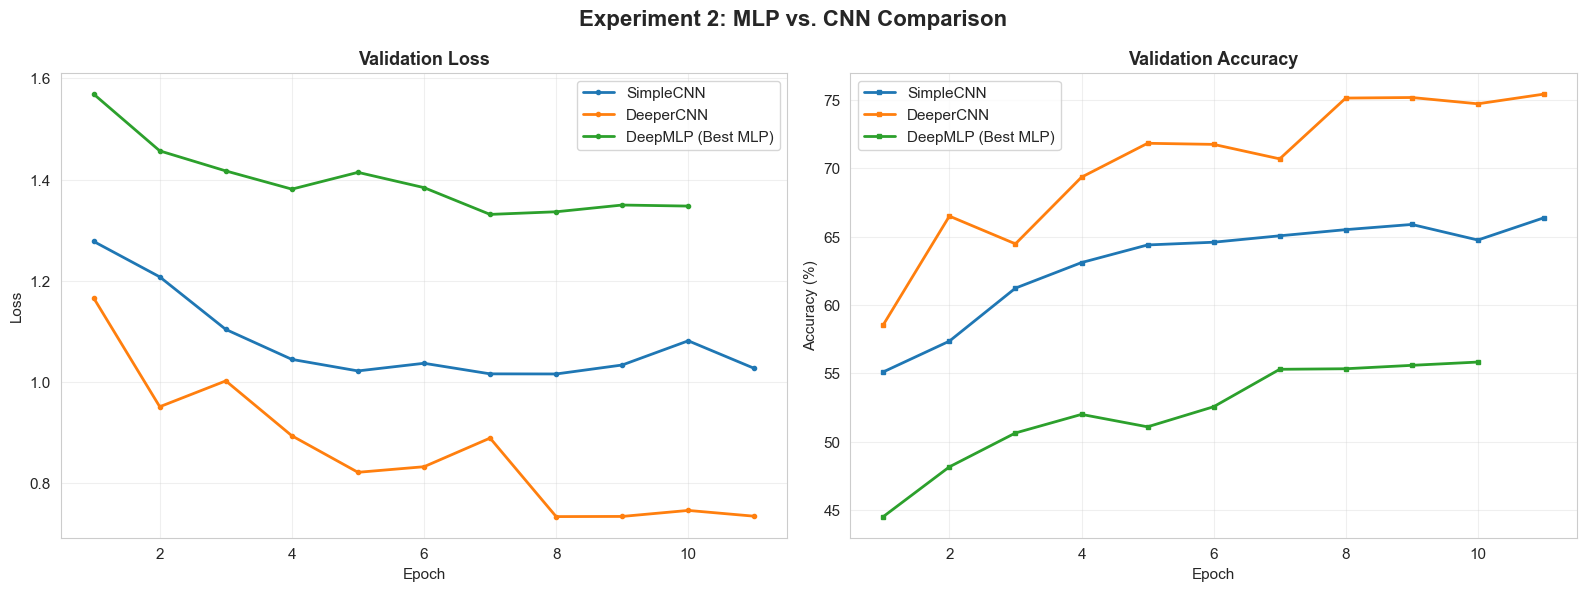


Parameter Efficiency Analysis:
  SimpleCNN                     : 0.0633 (acc% per 1K params)
  DeeperCNN                     : 0.0704 (acc% per 1K params)
  DeepMLP (Best MLP)            : 0.0660 (acc% per 1K params)


In [35]:
# Create comparison table
exp2_df = pd.DataFrame([
    {
        'Model': name,
        'Type': results['model'],
        'Parameters': f"{results['parameters']:,}",
        'Best Val Acc': f"{results['best_val_acc']:.2f}%",
        'Test Acc': f"{results['test_acc']:.2f}%",
        'Test Loss': f"{results['test_loss']:.4f}"
    }
    for name, results in exp2_results.items()
])

print("\n" + "="*90)
print("EXPERIMENT 2 RESULTS: MLP VS. CNN COMPARISON")
print("="*90)
print(exp2_df.to_string(index=False))
print("="*90 + "\n")

# Visualize learning curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Experiment 2: MLP vs. CNN Comparison', fontsize=16, fontweight='bold')

for name, results in exp2_results.items():
    history = results['history']

    # KORREKTUR: Dynamische Berechnung der Epochen für jedes Modell individuell
    epochs = range(1, len(history['val_loss']) + 1)
    
    # Validation Loss
    axes[0].plot(epochs, history['val_loss'], label=name, linewidth=2, marker='o', markersize=3)
    
    # Validation Accuracy
    axes[1].plot(epochs, history['val_acc'], label=name, linewidth=2, marker='s', markersize=3)

axes[0].set_title('Validation Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Validation Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/04_experiment2_mlp_vs_cnn.png', dpi=300, bbox_inches='tight')
print("✓ Saved: figures/04_experiment2_mlp_vs_cnn.png")
plt.show()

# Parameter efficiency analysis
print("\nParameter Efficiency Analysis:")
for name, results in exp2_results.items():
    params = results['parameters']
    acc = results['test_acc']
    efficiency = acc / (params / 1000)  # Accuracy per 1K parameters
    print(f"  {name:30s}: {efficiency:.4f} (acc% per 1K params)")

## 7. Experiment 3: Regularization Study

### Research Questions:
- How does dropout affect the train-val gap?
- Which dropout rate works best?
- Does batch normalization help?

### Experiments:
1. Train CNN without regularization (baseline)
2. Train with different dropout rates: 0.2, 0.3, 0.5
3. Compare with and without batch normalization

In [36]:
exp3_results = {}
learning_rate = 0.001
dropout_rates = [0.0, 0.2, 0.3, 0.5]

print("\n" + "="*70)
print("EXPERIMENT 3: REGULARIZATION STUDY")
print("="*70)

# Test different dropout rates with CNN
for dropout in dropout_rates:
    experiment_name = f"DeeperCNN_Dropout{dropout}"
    print(f"\n{'='*70}")
    print(f"Training: {experiment_name}")
    print(f"{'='*70}")
    
    run = wandb.init(
        project="neural-network-architecture-study",
        name=experiment_name,
        config={
            "architecture": "Deeper CNN",
            "dropout": dropout,
            "batch_norm": True,
            "learning_rate": learning_rate,
            "epochs": EPOCHS,
            "batch_size": BATCH_SIZE,
            "dataset": "CIFAR-10"
        },
        reinit=True
    )
    
    model = DeeperCNN(num_classes=10, dropout_rate=dropout, use_bn=True).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    wandb.config.update({"parameters": count_parameters(model)})
    
    history = train_model(
        model, train_loader, val_loader, criterion, optimizer,
        EPOCHS, device, experiment_name, use_wandb=True, patience=3, use_scheduler=True
    )
    
    test_loss, test_acc, test_prec, test_rec, test_f1, test_preds, test_labels = evaluate(
        model, test_loader, criterion, device
    )
    
    wandb.log({
        'test_loss': test_loss,
        'test_acc': test_acc,
        'test_precision': test_prec,
        'test_recall': test_rec,
        'test_f1': test_f1
    })
    
    exp3_results[experiment_name] = {
        'dropout': dropout,
        'batch_norm': True,
        'parameters': count_parameters(model),
        'history': history,
        'test_acc': test_acc,
        'test_loss': test_loss,
        'best_val_acc': max(history['val_acc']),
        'train_val_gap': history['train_acc'][history['val_acc'].index(max(history['val_acc']))] - max(history['val_acc'])
    }
    
    wandb.finish()

# Test without batch normalization (with dropout 0.3)
experiment_name = "DeeperCNN_NoBN_Dropout0.3"
print(f"\n{'='*70}")
print(f"Training: {experiment_name}")
print(f"{'='*70}")

run = wandb.init(
    project="neural-network-architecture-study",
    name=experiment_name,
    config={
        "architecture": "Deeper CNN",
        "dropout": 0.3,
        "batch_norm": False,
        "learning_rate": learning_rate,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "dataset": "CIFAR-10"
    },
    reinit=True
)

model = DeeperCNN(num_classes=10, dropout_rate=0.3, use_bn=False).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

wandb.config.update({"parameters": count_parameters(model)})

history = train_model(
    model, train_loader, val_loader, criterion, optimizer,
    EPOCHS, device, experiment_name, use_wandb=True, patience=3, use_scheduler=True
)

test_loss, test_acc, test_prec, test_rec, test_f1, test_preds, test_labels = evaluate(
    model, test_loader, criterion, device
)

wandb.log({
    'test_loss': test_loss,
    'test_acc': test_acc,
    'test_precision': test_prec,
    'test_recall': test_rec,
    'test_f1': test_f1
})

exp3_results[experiment_name] = {
    'dropout': 0.3,
    'batch_norm': False,
    'parameters': count_parameters(model),
    'history': history,
    'test_acc': test_acc,
    'test_loss': test_loss,
    'best_val_acc': max(history['val_acc']),
    'train_val_gap': history['train_acc'][history['val_acc'].index(max(history['val_acc']))] - max(history['val_acc'])
}

wandb.finish()

print("\n✓ Experiment 3 completed!")


EXPERIMENT 3: REGULARIZATION STUDY

Training: DeeperCNN_Dropout0.0



Training: DeeperCNN_Dropout0.0



→ New best validation loss: 1.0802
Epoch [ 1/15] | Time: 31.78s | Train Loss: 1.3101 | Train Acc: 52.86% | Val Loss: 1.0802 | Val Acc: 61.50%


→ New best validation loss: 1.0056
Epoch [ 2/15] | Time: 31.31s | Train Loss: 0.9562 | Train Acc: 66.06% | Val Loss: 1.0056 | Val Acc: 64.79%


→ New best validation loss: 0.9353
Epoch [ 3/15] | Time: 31.23s | Train Loss: 0.8222 | Train Acc: 71.05% | Val Loss: 0.9353 | Val Acc: 67.74%


...

→ No improvement for 1/3 epochs
Epoch [ 9/15] | Time: 32.31s | Train Loss: 0.4024 | Train Acc: 85.79% | Val Loss: 0.8725 | Val Acc: 72.32%


→ No improvement for 2/3 epochs
Epoch [10/15] | Time: 32.02s | Train Loss: 0.3484 | Train Acc: 87.75% | Val Loss: 0.8829 | Val Acc: 72.74%


→ No improvement for 3/3 epochs

Early Stopping triggered after 11 epochs!
No improvement in validation loss for 3 consecutive epochs.


Training completed!
Best Validation Accuracy: 73.97% (Epoch 11)
Best Validation Loss: 0.7998



epoch,▁▂▃▃▄▅▆▆▇█
epoch_time,█▁▁▂▃▅▆▂▆▄
test_acc,▁
test_f1,▁
test_loss,▁
test_precision,▁
test_recall,▁
train_acc,▁▄▅▅▆▆▇▇██
train_loss,█▆▄▄▃▃▂▂▁▁
val_acc,▁▄▇▆▇▇▇███
+4,...



✓ Experiment 3 completed!


### Experiment 3: Analysis and Visualization


EXPERIMENT 3 RESULTS: REGULARIZATION STUDY
               Experiment  Dropout Batch Norm Best Val Acc Test Acc Train-Val Gap
     DeeperCNN_Dropout0.0      0.0        Yes       75.52%   74.90%        20.04%
     DeeperCNN_Dropout0.2      0.2        Yes       75.80%   75.32%         8.78%
     DeeperCNN_Dropout0.3      0.3        Yes       75.10%   74.94%         6.02%
     DeeperCNN_Dropout0.5      0.5        Yes       73.51%   72.26%         0.69%
DeeperCNN_NoBN_Dropout0.3      0.3         No       73.97%   74.02%        18.48%

✓ Saved: figures/05_experiment3_regularization_effects.png


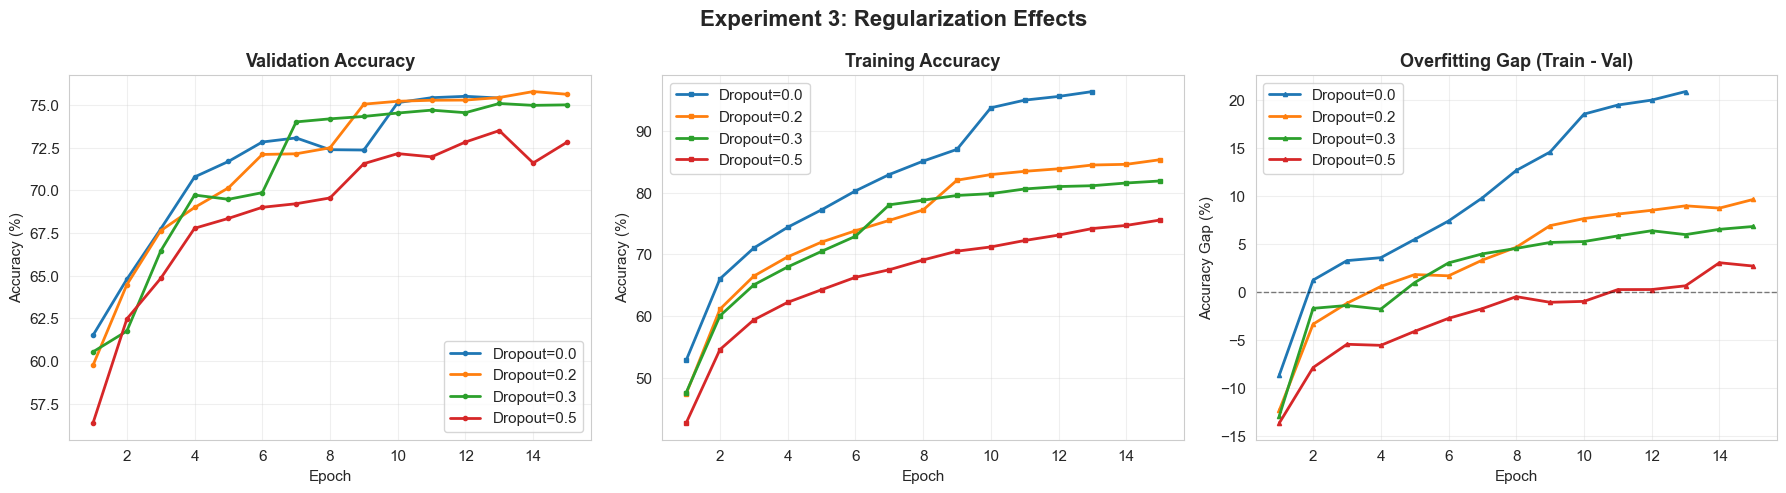

✓ Saved: figures/06_experiment3_dropout_comparison.png


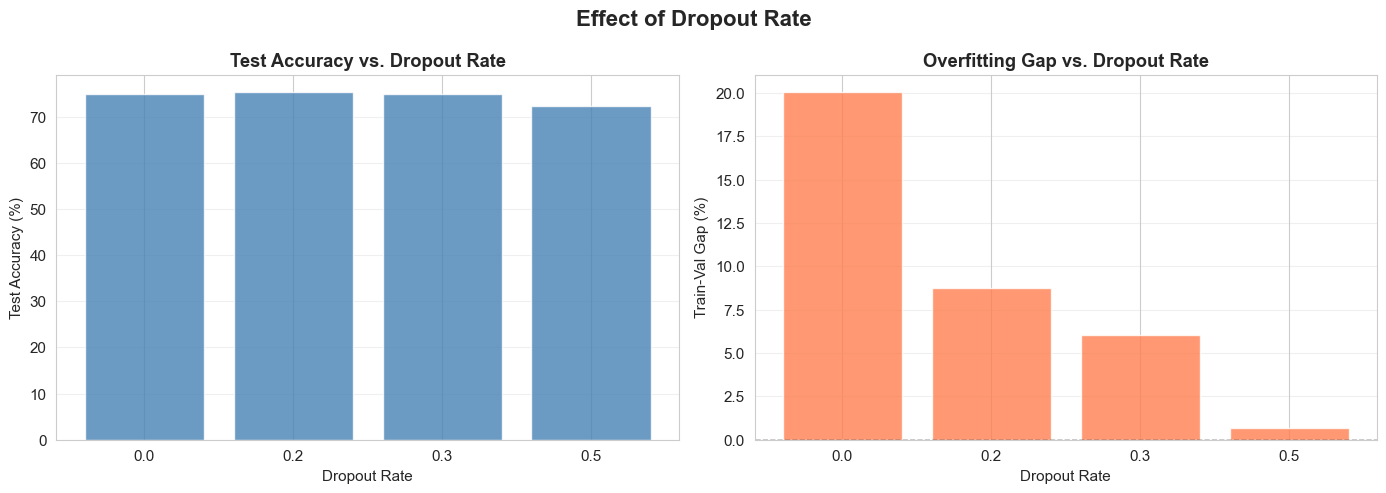

In [40]:
# Create comparison table
exp3_df = pd.DataFrame([
    {
        'Experiment': name,
        'Dropout': results['dropout'],
        'Batch Norm': 'Yes' if results['batch_norm'] else 'No',
        'Best Val Acc': f"{results['best_val_acc']:.2f}%",
        'Test Acc': f"{results['test_acc']:.2f}%",
        'Train-Val Gap': f"{results['train_val_gap']:.2f}%"
    }
    for name, results in exp3_results.items()
])

print("\n" + "="*90)
print("EXPERIMENT 3 RESULTS: REGULARIZATION STUDY")
print("="*90)
print(exp3_df.to_string(index=False))
print("="*90 + "\n")

# Visualize effect of dropout
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Experiment 3: Regularization Effects', fontsize=16, fontweight='bold')

for name, results in exp3_results.items():
    if results['batch_norm']:  # Only plot with batch norm for cleaner comparison
        history = results['history']
        label = f"Dropout={results['dropout']}"
        
        # KORREKTUR: Dynamische Länge basierend auf den tatsächlichen Daten dieses Modells
        epochs = range(1, len(history['val_acc']) + 1)

        # Validation Accuracy
        axes[0].plot(epochs, history['val_acc'], label=label, linewidth=2, marker='o', markersize=3)

        # Training Accuracy
        axes[1].plot(epochs, history['train_acc'], label=label, linewidth=2, marker='s', markersize=3)

        # Train-Val Gap
        gap = [train - val for train, val in zip(history['train_acc'], history['val_acc'])]
        axes[2].plot(epochs, gap, label=label, linewidth=2, marker='^', markersize=3)

axes[0].set_title('Validation Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Training Accuracy', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].set_title('Overfitting Gap (Train - Val)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy Gap (%)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.savefig('figures/05_experiment3_regularization_effects.png', dpi=300, bbox_inches='tight')
print("✓ Saved: figures/05_experiment3_regularization_effects.png")
plt.show()

# Dropout rate comparison bar chart
dropout_data = [(k, v['dropout'], v['test_acc'], v['train_val_gap']) 
                for k, v in exp3_results.items() if v['batch_norm']]
dropout_data.sort(key=lambda x: x[1])  # Sort by dropout rate

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Effect of Dropout Rate', fontsize=16, fontweight='bold')

dropouts = [x[1] for x in dropout_data]
test_accs = [x[2] for x in dropout_data]
gaps = [x[3] for x in dropout_data]

axes[0].bar(range(len(dropouts)), test_accs, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Dropout Rate')
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Test Accuracy vs. Dropout Rate', fontweight='bold')
axes[0].set_xticks(range(len(dropouts)))
axes[0].set_xticklabels([str(d) for d in dropouts])
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(range(len(dropouts)), gaps, color='coral', alpha=0.8)
axes[1].set_xlabel('Dropout Rate')
axes[1].set_ylabel('Train-Val Gap (%)')
axes[1].set_title('Overfitting Gap vs. Dropout Rate', fontweight='bold')
axes[1].set_xticks(range(len(dropouts)))
axes[1].set_xticklabels([str(d) for d in dropouts])
axes[1].grid(axis='y', alpha=0.3)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.savefig('figures/06_experiment3_dropout_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: figures/06_experiment3_dropout_comparison.png")
plt.show()

## 8. Experiment 4: Learning Rate Study

### Research Questions:
- Which learning rate converges fastest?
- Which learning rate gives best final accuracy?
- Any learning rates that fail to converge?
- Trade-off between speed and final performance?

### Experiments:
- Train best CNN architecture with lr = 0.1, 0.01, 0.001, 0.0001
- Analyze convergence speed and stability

In [38]:
exp4_results = {}
learning_rates = [0.1, 0.01, 0.001, 0.0001]

print("\n" + "="*70)
print("EXPERIMENT 4: LEARNING RATE STUDY")
print("="*70)

# Use best configuration from Experiment 3
best_dropout = 0.3

for lr in learning_rates:
    experiment_name = f"DeeperCNN_LR{lr}"
    print(f"\n{'='*70}")
    print(f"Training: {experiment_name}")
    print(f"{'='*70}")
    
    run = wandb.init(
        project="neural-network-architecture-study",
        name=experiment_name,
        config={
            "architecture": "Deeper CNN",
            "dropout": best_dropout,
            "batch_norm": True,
            "learning_rate": lr,
            "epochs": EPOCHS,
            "batch_size": BATCH_SIZE,
            "dataset": "CIFAR-10"
        },
        reinit=True
    )
    
    model = DeeperCNN(num_classes=10, dropout_rate=best_dropout, use_bn=True).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    wandb.config.update({"parameters": count_parameters(model)})
    
    history = train_model(
        model, train_loader, val_loader, criterion, optimizer,
        EPOCHS, device, experiment_name, use_wandb=True, patience=3, use_scheduler=True
    )
    
    test_loss, test_acc, test_prec, test_rec, test_f1, test_preds, test_labels = evaluate(
        model, test_loader, criterion, device
    )
    
    wandb.log({
        'test_loss': test_loss,
        'test_acc': test_acc,
        'test_precision': test_prec,
        'test_recall': test_rec,
        'test_f1': test_f1
    })
    
    # Find convergence epoch (when val acc reaches 90% of final value)
    final_acc = max(history['val_acc'])
    convergence_threshold = 0.9 * final_acc
    convergence_epoch = next((i+1 for i, acc in enumerate(history['val_acc']) 
                              if acc >= convergence_threshold), EPOCHS)
    
    exp4_results[experiment_name] = {
        'learning_rate': lr,
        'history': history,
        'test_acc': test_acc,
        'test_loss': test_loss,
        'best_val_acc': max(history['val_acc']),
        'convergence_epoch': convergence_epoch,
        'final_val_loss': history['val_loss'][-1]
    }
    
    wandb.finish()

print("\n✓ Experiment 4 completed!")


EXPERIMENT 4: LEARNING RATE STUDY

Training: DeeperCNN_LR0.1



Training: DeeperCNN_LR0.1



→ New best validation loss: 2.3093
Epoch [ 1/15] | Time: 31.55s | Train Loss: 12.7858 | Train Acc: 9.97% | Val Loss: 2.3093 | Val Acc: 10.24%


→ New best validation loss: 2.3073
Epoch [ 2/15] | Time: 30.80s | Train Loss: 2.3078 | Train Acc: 10.26% | Val Loss: 2.3073 | Val Acc: 10.35%


→ No improvement for 1/3 epochs
Epoch [ 3/15] | Time: 31.18s | Train Loss: 2.3081 | Train Acc: 10.16% | Val Loss: 2.3105 | Val Acc: 9.98%


...

→ New best validation loss: 0.8122
Epoch [13/15] | Time: 31.22s | Train Loss: 0.6311 | Train Acc: 78.36% | Val Loss: 0.8122 | Val Acc: 71.57%


→ No improvement for 1/3 epochs
Epoch [14/15] | Time: 31.46s | Train Loss: 0.6003 | Train Acc: 79.64% | Val Loss: 0.8148 | Val Acc: 71.17%


→ New best validation loss: 0.8050
Epoch [15/15] | Time: 31.28s | Train Loss: 0.5762 | Train Acc: 80.22% | Val Loss: 0.8050 | Val Acc: 71.72%

Training completed!
Best Validation Accuracy: 71.72% (Epoch 15)
Best Validation Loss: 0.8050



epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
epoch_time,▅▂▁▄▆▄▇█▂▃▇▆▄▅▄
test_acc,▁
test_f1,▁
test_loss,▁
test_precision,▁
test_recall,▁
train_acc,▁▃▄▅▆▆▆▆▇▇▇▇███
train_loss,█▆▅▄▄▃▃▃▂▂▂▂▁▁▁
val_acc,▁▃▅▅▆▆▇▇▇▇█████
+4,...



✓ Experiment 4 completed!


### Experiment 4: Analysis and Visualization


EXPERIMENT 4 RESULTS: LEARNING RATE STUDY
 Learning Rate Best Val Acc Test Acc Final Val Loss  Convergence Epoch
        0.1000       10.35%   10.00%         2.3028                  1
        0.0100       64.93%   63.86%         1.0728                  9
        0.0010       76.35%   75.55%         0.7156                  5
        0.0001       71.72%   71.78%         0.8050                  4

✓ Saved: figures/07_experiment4_learning_rate.png


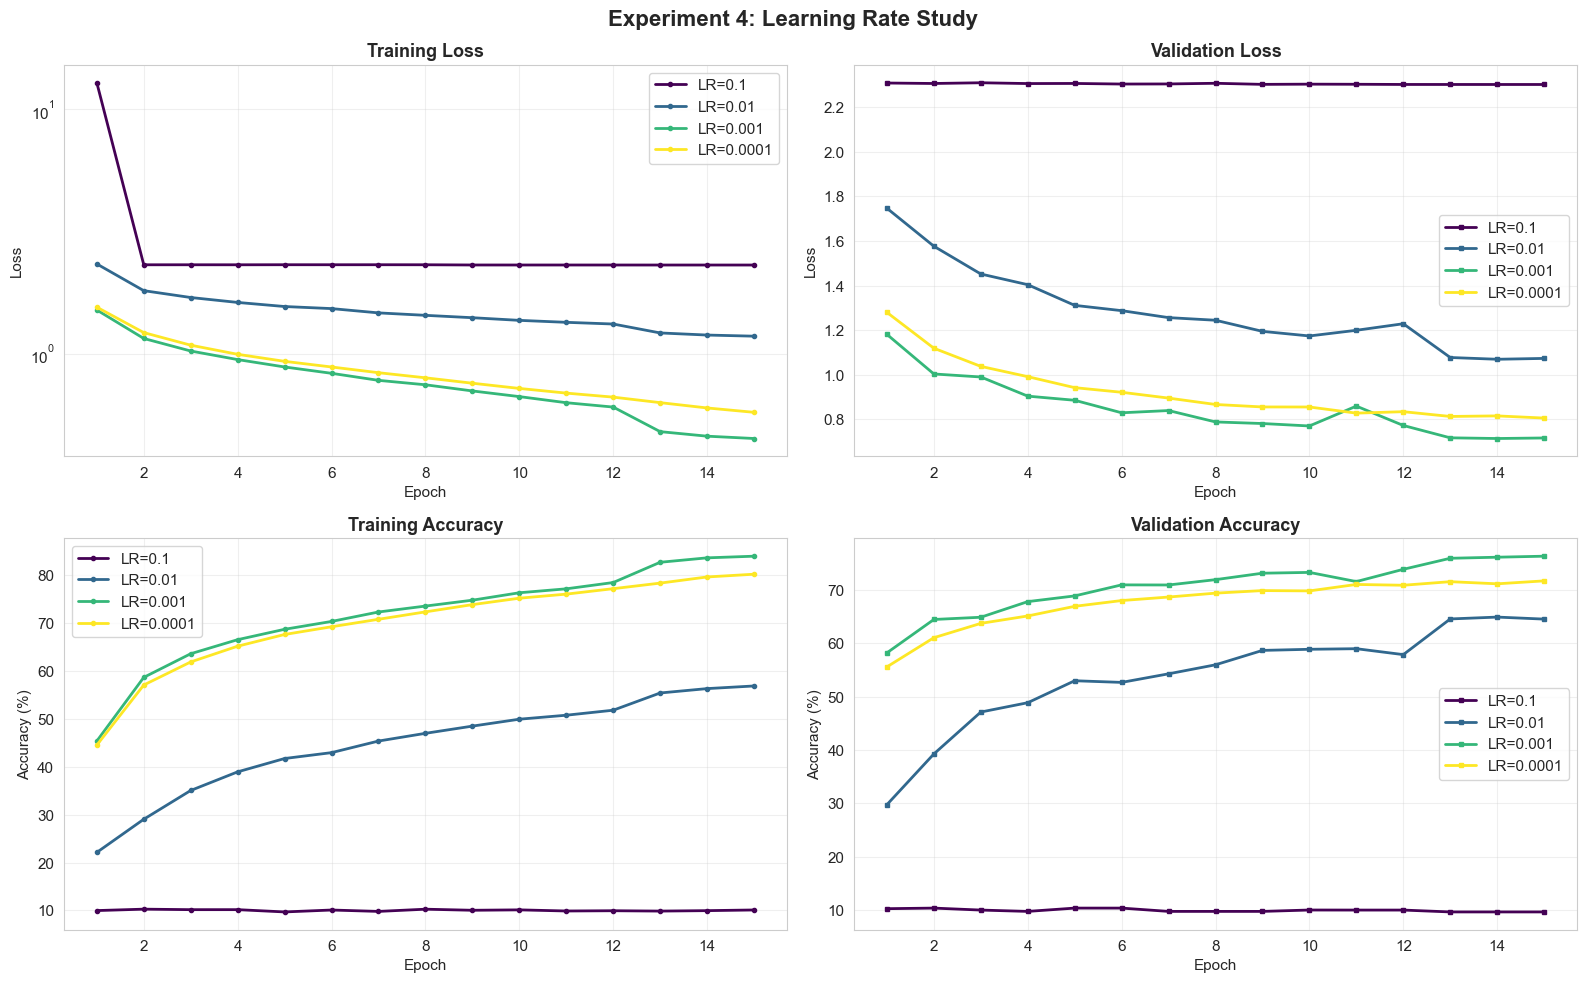


Convergence Speed Analysis:
  LR=0.1000: Converged at epoch  1, Final Acc: 10.35%
  LR=0.0001: Converged at epoch  4, Final Acc: 71.72%
  LR=0.0010: Converged at epoch  5, Final Acc: 76.35%
  LR=0.0100: Converged at epoch  9, Final Acc: 64.93%


In [41]:
# Create comparison table
exp4_df = pd.DataFrame([
    {
        'Learning Rate': results['learning_rate'],
        'Best Val Acc': f"{results['best_val_acc']:.2f}%",
        'Test Acc': f"{results['test_acc']:.2f}%",
        'Final Val Loss': f"{results['final_val_loss']:.4f}",
        'Convergence Epoch': results['convergence_epoch']
    }
    for name, results in exp4_results.items()
])
exp4_df = exp4_df.sort_values('Learning Rate', ascending=False)

print("\n" + "="*90)
print("EXPERIMENT 4 RESULTS: LEARNING RATE STUDY")
print("="*90)
print(exp4_df.to_string(index=False))
print("="*90 + "\n")

# Visualize learning curves for different learning rates
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Experiment 4: Learning Rate Study', fontsize=16, fontweight='bold')

epochs = range(1, EPOCHS + 1)
colors = plt.cm.viridis(np.linspace(0, 1, len(exp4_results)))

for idx, (name, results) in enumerate(sorted(exp4_results.items(), 
                                              key=lambda x: x[1]['learning_rate'], reverse=True)):
    history = results['history']
    label = f"LR={results['learning_rate']}"
    
    # Training Loss
    axes[0, 0].plot(epochs, history['train_loss'], label=label, 
                   color=colors[idx], linewidth=2, marker='o', markersize=3)
    
    # Validation Loss
    axes[0, 1].plot(epochs, history['val_loss'], label=label,
                   color=colors[idx], linewidth=2, marker='s', markersize=3)
    
    # Training Accuracy
    axes[1, 0].plot(epochs, history['train_acc'], label=label,
                   color=colors[idx], linewidth=2, marker='o', markersize=3)
    
    # Validation Accuracy
    axes[1, 1].plot(epochs, history['val_acc'], label=label,
                   color=colors[idx], linewidth=2, marker='s', markersize=3)

axes[0, 0].set_title('Training Loss', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_yscale('log')

axes[0, 1].set_title('Validation Loss', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].set_title('Training Accuracy', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy (%)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].set_title('Validation Accuracy', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/07_experiment4_learning_rate.png', dpi=300, bbox_inches='tight')
print("✓ Saved: figures/07_experiment4_learning_rate.png")
plt.show()

# Convergence speed analysis
print("\nConvergence Speed Analysis:")
for name, results in sorted(exp4_results.items(), key=lambda x: x[1]['convergence_epoch']):
    print(f"  LR={results['learning_rate']:6.4f}: Converged at epoch {results['convergence_epoch']:2d}, "
          f"Final Acc: {results['best_val_acc']:.2f}%")

## 9. Final Summary and Overall Comparison

Comprehensive comparison of all experiments and architectures.

In [44]:
# Collect best models from each experiment
best_models = {}

# Best from Experiment 1
best_exp1 = max(exp1_results.items(), key=lambda x: x[1]['test_acc'])
best_models['Best MLP (Exp 1)'] = best_exp1[1]

# Best from Experiment 2
best_exp2 = max(exp2_results.items(), key=lambda x: x[1]['test_acc'])
best_models['Best CNN (Exp 2)'] = best_exp2[1]

# Best from Experiment 3
best_exp3 = max(exp3_results.items(), key=lambda x: x[1]['test_acc'])
best_models['Best Regularization (Exp 3)'] = best_exp3[1]

# Best from Experiment 4
best_exp4 = max(exp4_results.items(), key=lambda x: x[1]['test_acc'])
best_models['Best Learning Rate (Exp 4)'] = best_exp4[1]

# Create comprehensive comparison table
print("\n" + "="*100)
print("FINAL SUMMARY: BEST MODELS FROM EACH EXPERIMENT")
print("="*100)

summary_data = []
for name, results in best_models.items():
    summary_data.append({
        'Experiment': name,
        'Parameters': f"{results.get('parameters', 0):,}",
        'Best Val Acc': f"{results.get('best_val_acc', 0):.2f}%",
        'Test Acc': f"{results.get('test_acc', 0):.2f}%",
        'Test Loss': f"{results.get('test_loss', 0):.4f}"
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print("="*100 + "\n")

# Overall best model
overall_best = max(best_models.items(), key=lambda x: x[1].get('test_acc', 0))
print(f"\n🏆 OVERALL BEST MODEL: {overall_best[0]}")
print(f"   Test Accuracy: {overall_best[1].get('test_acc', 0):.2f}%")
print(f"   Parameters: {overall_best[1].get('parameters', 0):,}")
print(f"   Test Loss: {overall_best[1].get('test_loss', 0):.4f}\n")


FINAL SUMMARY: BEST MODELS FROM EACH EXPERIMENT
                 Experiment Parameters Best Val Acc Test Acc Test Loss
           Best MLP (Exp 1)    828,490       55.82%   54.65%    1.3541
           Best CNN (Exp 2)  1,070,986       75.43%   75.44%    0.7430
Best Regularization (Exp 3)  1,070,986       75.80%   75.32%    0.7337
 Best Learning Rate (Exp 4)          0       76.35%   75.55%    0.7383


🏆 OVERALL BEST MODEL: Best Learning Rate (Exp 4)
   Test Accuracy: 75.55%
   Parameters: 0
   Test Loss: 0.7383



### Confusion Matrix and Misclassification Analysis

✓ Saved: figures/08_confusion_matrix.png


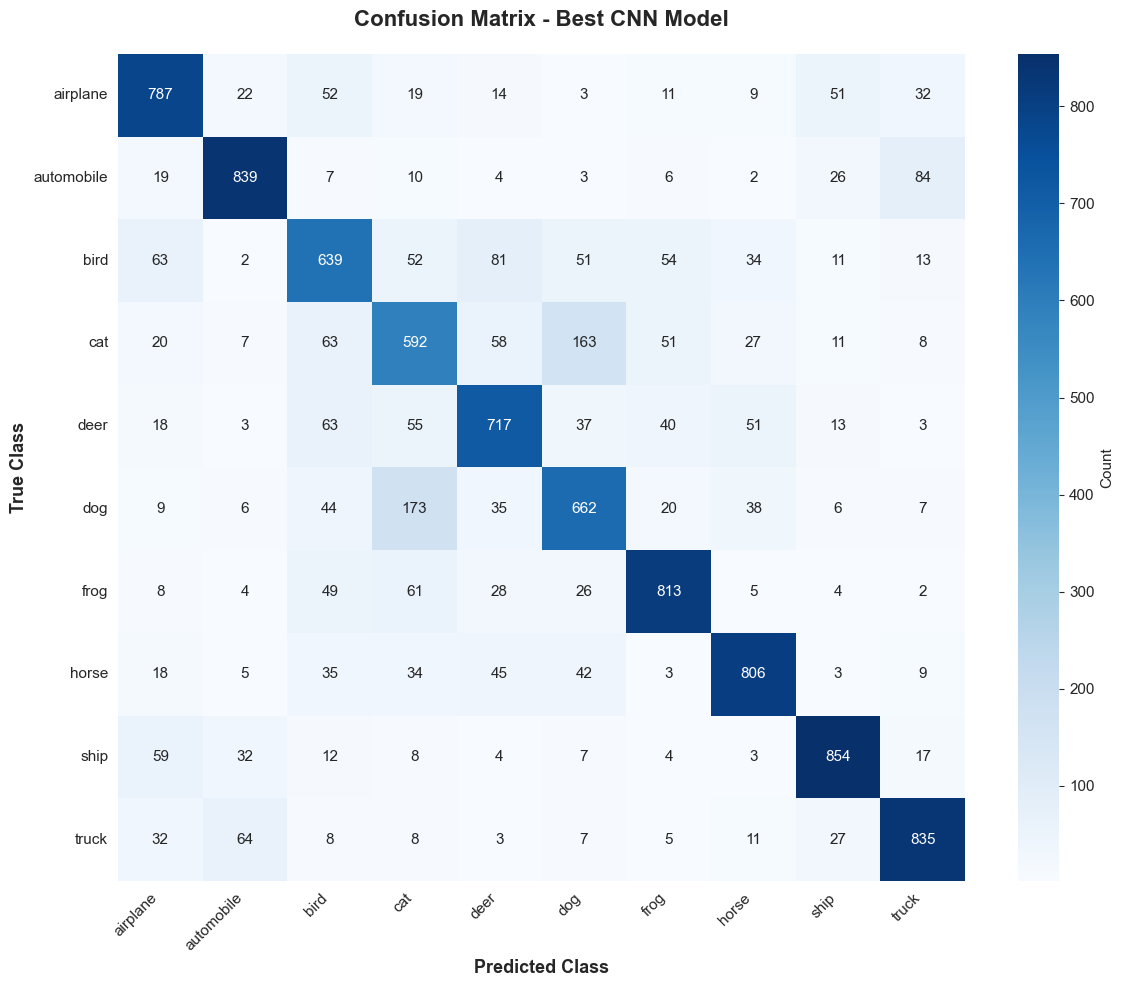

✓ Saved: figures/09_per_class_accuracy.png


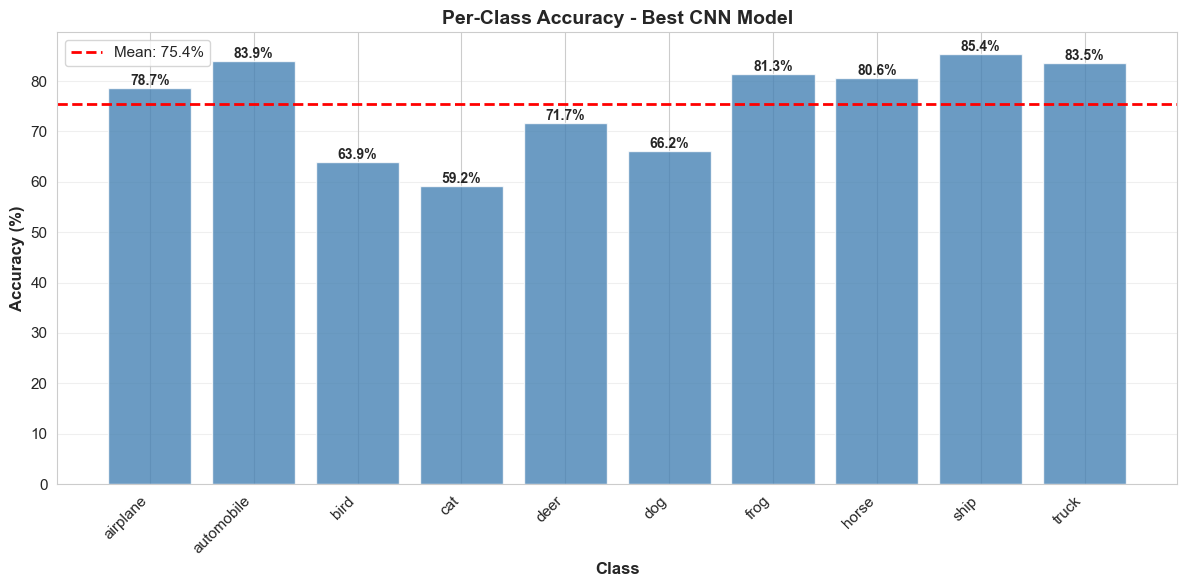


Per-Class Performance:
  airplane    : 78.70%
  automobile  : 83.90%
  bird        : 63.90%
  cat         : 59.20%
  deer        : 71.70%
  dog         : 66.20%
  frog        : 81.30%
  horse       : 80.60%
  ship        : 85.40%
  truck       : 83.50%

  Average:       75.44%


In [45]:
# Get predictions from best model (from Experiment 2)
best_cnn = exp2_results['DeeperCNN']
cm = confusion_matrix(best_cnn['test_labels'], best_cnn['test_preds'])

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CIFAR10_CLASSES, yticklabels=CIFAR10_CLASSES,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Best CNN Model', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Class', fontsize=13, fontweight='bold')
plt.ylabel('True Class', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('figures/08_confusion_matrix.png', dpi=300, bbox_inches='tight')
print("✓ Saved: figures/08_confusion_matrix.png")
plt.show()

# Per-class accuracy
class_accuracies = cm.diagonal() / cm.sum(axis=1) * 100

plt.figure(figsize=(12, 6))
bars = plt.bar(range(10), class_accuracies, color='steelblue', alpha=0.8)
plt.xlabel('Class', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
plt.title('Per-Class Accuracy - Best CNN Model', fontsize=14, fontweight='bold')
plt.xticks(range(10), CIFAR10_CLASSES, rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.axhline(y=class_accuracies.mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Mean: {class_accuracies.mean():.1f}%')
plt.legend()

# Add value labels on bars
for idx, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/09_per_class_accuracy.png', dpi=300, bbox_inches='tight')
print("✓ Saved: figures/09_per_class_accuracy.png")
plt.show()

print("\nPer-Class Performance:")
for idx, acc in enumerate(class_accuracies):
    print(f"  {CIFAR10_CLASSES[idx]:12s}: {acc:5.2f}%")
print(f"\n  Average:       {class_accuracies.mean():5.2f}%")

## 10. Export Results for Paper

Save all results and figures for the research paper.

In [46]:
# Create results directory
os.makedirs('results', exist_ok=True)

# Save comparison tables
exp1_df.to_csv('results/experiment1_results.csv', index=False)
exp2_df.to_csv('results/experiment2_results.csv', index=False)
exp3_df.to_csv('results/experiment3_results.csv', index=False)
exp4_df.to_csv('results/experiment4_results.csv', index=False)
summary_df.to_csv('results/final_summary.csv', index=False)

print("✓ Results exported to 'results/' directory")
print("\nFiles created:")
print("  - experiment1_results.csv")
print("  - experiment2_results.csv")
print("  - experiment3_results.csv")
print("  - experiment4_results.csv")
print("  - final_summary.csv")

print("\n" + "="*70)
print("ALL EXPERIMENTS COMPLETED SUCCESSFULLY!")
print("="*70)
print("\nNext steps:")
print("1. Review results in Weights & Biases dashboard")
print("2. Write research paper using the exported results")
print("3. Include visualizations from this notebook")
print("4. Discuss architectural trade-offs and findings")
print("="*70)

✓ Results exported to 'results/' directory

Files created:
  - experiment1_results.csv
  - experiment2_results.csv
  - experiment3_results.csv
  - experiment4_results.csv
  - final_summary.csv

ALL EXPERIMENTS COMPLETED SUCCESSFULLY!

Next steps:
1. Review results in Weights & Biases dashboard
2. Write research paper using the exported results
3. Include visualizations from this notebook
4. Discuss architectural trade-offs and findings
